<img src="https://m.faithful-to-nature.co.za/media/brands/thumbnail/4644/Bellabeat_logo-02.jpg" alt="Bellabeat Logo" />


## The Company

  Founded in 2013 by Urška Sršen and Sando Mur, Bellabeat is a wellness tech company creating beautifully designed smart products for women. The company tracks activity, sleep, stress, and reproductive health to empower women with insights into their well-being. By 2016, Bellabeat expanded globally, selling products through online retailers and its own e-commerce platform. The company focuses on digital marketing, including Google Search, social media, YouTube ads, and the Google Display Network, alongside traditional advertising. For more details you can check the website here [BellaBeat](<https://bellabeat.com/>)

## 1. Ask Phase

####  Questions

  * We want to find out how the customers are using the BellaBeat devices trought out their day, like Leaf for example
  * By analysing the data from the devices will we discover some trends or patterns that could lead to insihgts.

### Business Task

*How do women use Leaf throughout their daily routines and how does it impact their health and wellness?*

### Setting up my environment
  Setting up my environment by loading some packages

In [ ]:

library(tidyverse)
library(lubridate)
library(dplyr)
library(ggplot2)
library(tidyr)
library(readr)
library(janitor)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




## 2. Prepare Phase

#### Importing DataSets
  
  For this case study I will use the FitBit Fitness Tracker [DataSet](<https://www.kaggle.com/datasets/arashnic/fitbit>)

In [ ]:
activity <- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")
calories <- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyCalories_merged.csv")
intensities <- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyIntensities_merged.csv")
steps <- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailySteps_merged.csv")
sleep <- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")
weight <- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/weightLogInfo_merged.csv")


  * **Data Storage**
    + We get access to the data by the *FitBit Fitness Tracker Data* DataSet, available on Kaggle.
    + The data is storage in csv format, being easy and pratical to work with. They are in long format
  * **Bias and Credibility** 
    + The dataset has a *sample bias* because it includes data from only 30 participants, wich is not representative of the entire population, it fails capturing the diversity of the population;
    + We can follow the ROCCC protocol to check the credibility of the dataset:
      + **Representatives**: We have a limitation because it only contains 30 participants;
      + **Objectivity**: The collection relied on wearable devices, wich likely reduce self-reporting errors.But in the other hand differences in FitBit tracker models and user behaviors may influence the data;
      + **Completeness**: The dataset provides detailed information about physical activity , heart rate and sleep;
      + **Consistency**: It uses timestamps and session IDs that allows clear data parsing;
      + **Currency**: The dataset is outdated, having 8 years, wich may not represent the current population;

## 3. Process Phase

### Cleanning and Summary

  I have checked the duplicates through the dataset, only finding in the daile_sleep data.

In [ ]:

print(sum(duplicated(activity)))
print(sum(duplicated(calories)))
print(sum(duplicated(intensities)))
print(sum(duplicated(steps)))
print(sum(duplicated(sleep)))
print(sum(duplicated(weight)))

sleep_new <- sleep %>% distinct()


[1] 0


[1] 0


[1] 0


[1] 0


[1] 3


[1] 0


  + Summarizing the data to get to know about the dataset.

In [ ]:
#Atividade
activity %>% 
  select(TotalSteps,
         TotalDistance,
         Calories,
         SedentaryMinutes) %>% 
  summary()

#Calorias gastas
calories %>% 
  select(Calories) %>% 
  summary()

#Sono
sleep_new %>% 
  select(TotalSleepRecords,
         TotalTimeInBed,
         TotalMinutesAsleep) %>% 
  summary()

#Adicionar a coluna da Altura, através da fórumla do BMI

weight_new <- weight %>% 
  mutate(height= sqrt(WeightKg/BMI))
head(weight_new)
#Peso
weight_new %>% 
  select(WeightKg,
         Fat,
         BMI,
         height) %>% 
  summary()

   TotalSteps    TotalDistance       Calories    SedentaryMinutes
 Min.   :    0   Min.   : 0.000   Min.   :   0   Min.   :   0.0  
 1st Qu.: 3790   1st Qu.: 2.620   1st Qu.:1828   1st Qu.: 729.8  
 Median : 7406   Median : 5.245   Median :2134   Median :1057.5  
 Mean   : 7638   Mean   : 5.490   Mean   :2304   Mean   : 991.2  
 3rd Qu.:10727   3rd Qu.: 7.713   3rd Qu.:2793   3rd Qu.:1229.5  
 Max.   :36019   Max.   :28.030   Max.   :4900   Max.   :1440.0  

    Calories   
 Min.   :   0  
 1st Qu.:1828  
 Median :2134  
 Mean   :2304  
 3rd Qu.:2793  
 Max.   :4900  

 TotalSleepRecords TotalTimeInBed  TotalMinutesAsleep
 Min.   :1.00      Min.   : 61.0   Min.   : 58.0     
 1st Qu.:1.00      1st Qu.:403.8   1st Qu.:361.0     
 Median :1.00      Median :463.0   Median :432.5     
 Mean   :1.12      Mean   :458.5   Mean   :419.2     
 3rd Qu.:1.00      3rd Qu.:526.0   3rd Qu.:490.0     
 Max.   :3.00      Max.   :961.0   Max.   :796.0     

,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId,height
,<dbl>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<dbl>
1,1503960366,5/2/2016 11:59:59 PM,52.6,115.9631,22,22.65,True,1.462234e+12,1.523908
2,1503960366,5/3/2016 11:59:59 PM,52.6,115.9631,NA,22.65,True,1.462320e+12,1.523908
3,1927972279,4/13/2016 1:08:52 AM,133.5,294.3171,NA,47.54,False,1.460510e+12,1.675757
4,2873212765,4/21/2016 11:59:59 PM,56.7,125.0021,NA,21.45,True,1.461283e+12,1.625840
5,2873212765,5/12/2016 11:59:59 PM,57.3,126.3249,NA,21.69,True,1.463098e+12,1.625352
6,4319703577,4/17/2016 11:59:59 PM,72.4,159.6147,25,27.45,True,1.460938e+12,1.624045


    WeightKg           Fat             BMI            height     
 Min.   : 52.60   Min.   :22.00   Min.   :21.45   Min.   :1.524  
 1st Qu.: 61.40   1st Qu.:22.75   1st Qu.:23.96   1st Qu.:1.601  
 Median : 62.50   Median :23.50   Median :24.39   Median :1.601  
 Mean   : 72.04   Mean   :23.50   Mean   :25.19   Mean   :1.685  
 3rd Qu.: 85.05   3rd Qu.:24.25   3rd Qu.:25.56   3rd Qu.:1.828  
 Max.   :133.50   Max.   :25.00   Max.   :47.54   Max.   :1.828  
                  NA's   :65                                     

### Interesting Observations

  + The WHO, World Health Organization, recommends that each person engages in physical activity, like 10,000 steps per day. In this study, participants have an average of 7,638 steps per day;
  + In the Sleep summary we can see that on average, participants spend 7 hours and 38 minutos in bed, but only 6 of are actually spent sleeping;
  + In average the participants spend 1 hour and 39 minutes of their day sedentary.

## 4. Analysis Phase

### Merging data


In [ ]:
calories_weight <- full_join(calories,weight_new,by = "Id")
head(calories_weight)

Warning message in full_join(calories, weight_new, by = "Id"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


,Id,ActivityDay,Calories,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId,height
,<dbl>,<chr>,<int>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<dbl>
1,1503960366,4/12/2016,1985,5/2/2016 11:59:59 PM,52.6,115.9631,22,22.65,True,1.462234e+12,1.523908
2,1503960366,4/12/2016,1985,5/3/2016 11:59:59 PM,52.6,115.9631,NA,22.65,True,1.462320e+12,1.523908
3,1503960366,4/13/2016,1797,5/2/2016 11:59:59 PM,52.6,115.9631,22,22.65,True,1.462234e+12,1.523908
4,1503960366,4/13/2016,1797,5/3/2016 11:59:59 PM,52.6,115.9631,NA,22.65,True,1.462320e+12,1.523908
5,1503960366,4/14/2016,1776,5/2/2016 11:59:59 PM,52.6,115.9631,22,22.65,True,1.462234e+12,1.523908
6,1503960366,4/14/2016,1776,5/3/2016 11:59:59 PM,52.6,115.9631,NA,22.65,True,1.462320e+12,1.523908


### Visualization
  
  
  First we will compare the **Steps** with the **Sedentary Time** to see if we have some relation between them.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


`geom_smooth()` using formula = 'y ~ x'


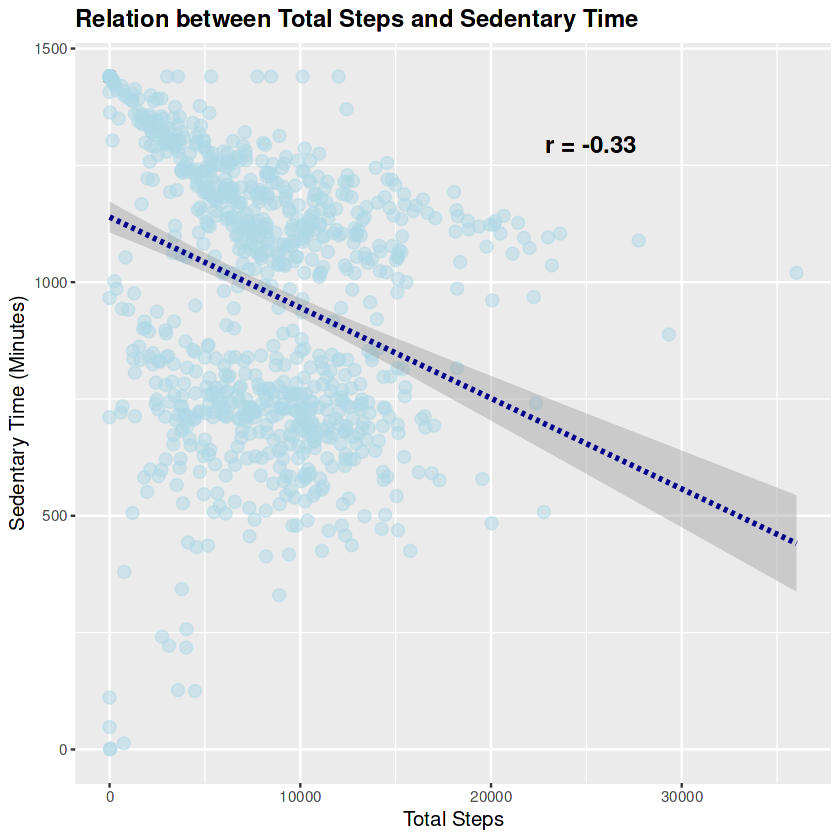

In [ ]:
correlation_steps_sedentary <- cor(activity$TotalSteps, activity$SedentaryMinutes)


ggplot(activity,aes( x= TotalSteps, y = SedentaryMinutes)) + 
  geom_point(color = "lightblue",size = 3, alpha = 0.5) + 
  geom_smooth(method = "lm", color = "darkblue", size = 1.2, linetype = "dashed") +
  labs(title = "Relation between Total Steps and Sedentary Time",
       x = "Total Steps",
       y = "Sedentary Time (Minutes)") +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.title.x = element_text(size = 12),
    axis.title.y = element_text(size = 12)
  ) +
  annotate("text", 
         x = max(activity$TotalSteps) * 0.7,  # Adjust the position of the text
         y = max(activity$SedentaryMinutes) * 0.9,  # Adjust the position of the text
         label = paste("r =", round(correlation_steps_sedentary, 2)),  # Add correlation coefficient
         size = 5, color = "black", fontface = "bold")  # Text formatting


 + We can see that as the total number of steps increases, the time spent being sedentary tends to decrease
 + There is a variability in sedentary time for those with low step counts;
 + But higher step counts show less variation, as they consistently exhibit lower sedentary minutes;
 

  Next we can compare the **Total of Steps** with the **Calories Burned**

`geom_smooth()` using formula = 'y ~ x'


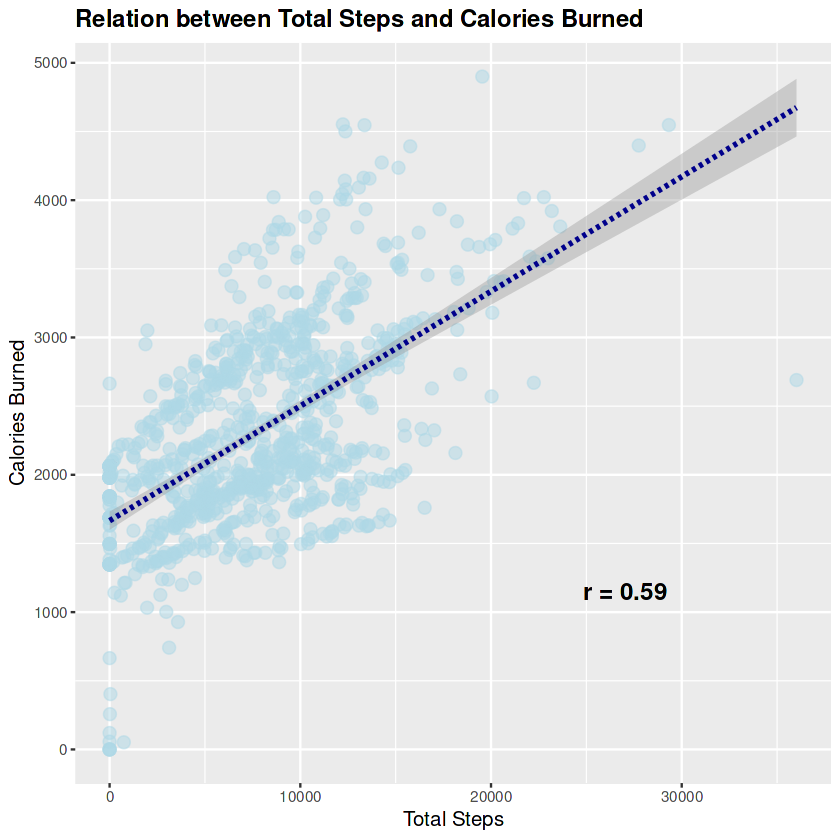

In [ ]:
correlation_steps_calorias <- cor(activity$TotalSteps, activity$Calories)

ggplot(activity, aes(x= TotalSteps, y = Calories)) +
  geom_point(color = "lightblue", size = 3, alpha = 0.5) + 
  geom_smooth(method = "lm", color = "darkblue", size = 1.2, linetype = "dashed") + 
  labs(title = "Relation between Total Steps and Calories Burned",
       x = "Total Steps",
       y = "Calories Burned") + 
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.title.x = element_text(size = 12),
    axis.title.y = element_text(size = 12)
  ) +
  annotate("text",
           x = max(activity$TotalSteps) * 0.75,  # Adjust the position of the text
           y = max(activity$SedentaryMinutes) * 0.8,  # Adjust the position of the text
           label = paste("r =", round(correlation_steps_calorias, 2)),  # Add correlation coefficient
           size = 5, color = "black", fontface = "bold")  # Text formatting

  + We can see that as the total number of steps increases, the calories burned tends to increase to;
  + The range extends from 0 to approximately 30,000 steps, showing diversity in the participant activity levels;
  
  Now we will see the **Distribution off Sleep Efficiency**

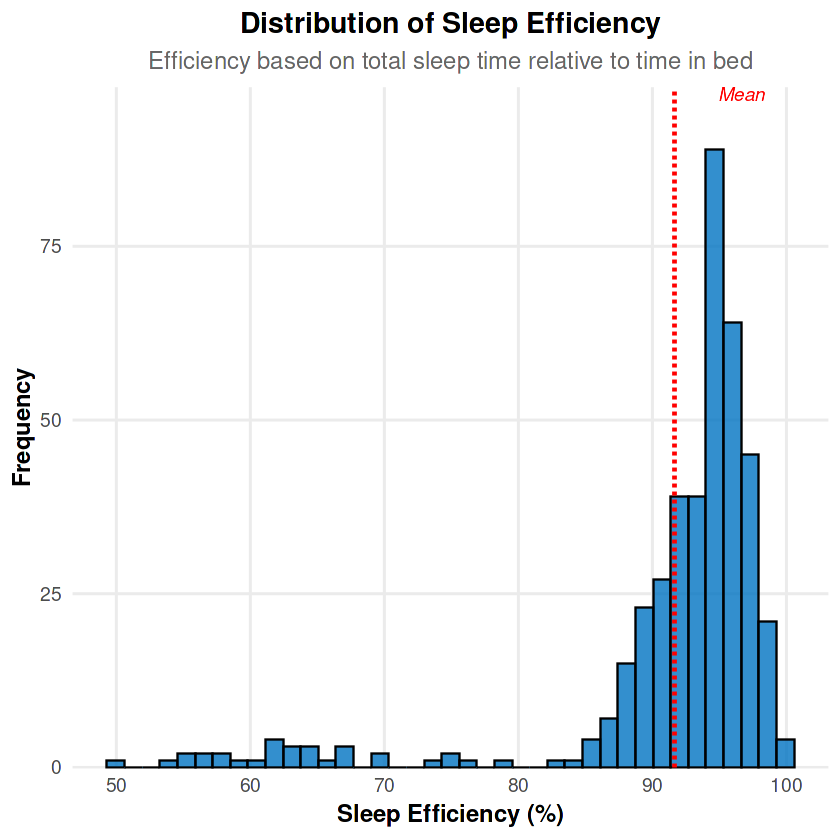

In [ ]:
sleep_new <- sleep_new %>% 
  mutate(efficiency = sleep_new$TotalMinutesAsleep / sleep_new$TotalTimeInBed * 100)

# Calculate binwidth dynamically
bin_width <- 2 * IQR(sleep_new$efficiency, na.rm = TRUE) / length(sleep_new$efficiency)^(1/3)

# Calculate efficiency
sleep_new <- sleep_new %>%
  mutate(efficiency = (TotalMinutesAsleep / TotalTimeInBed) * 100)

# Create the histogram
ggplot(sleep_new, aes(x = efficiency)) +
  geom_histogram(
    binwidth = bin_width,
    fill = "#0073C2", 
    color = "black",
    alpha = 0.8
  ) +
  geom_vline(
    aes(xintercept = mean(efficiency, na.rm = TRUE)), 
    color = "red", linetype = "dashed", linewidth = 1
  ) +
  annotate(
    "text", x = mean(sleep_new$efficiency, na.rm = TRUE) + 5, y = Inf,
    label = "Mean", vjust = 1, color = "red", fontface = "italic"
  ) +
  labs(
    title = "Distribution of Sleep Efficiency",
    subtitle = "Efficiency based on total sleep time relative to time in bed",
    x = "Sleep Efficiency (%)",
    y = "Frequency"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5, color = "gray40"),
    axis.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  ) +
  scale_x_continuous(breaks = seq(0, 100, by = 10)) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1)))

  + Most participants are getting good quality sleep, as indicated by the high concentration near 90-100% range;


  Lastly we will check the **Sleep Efficiency across Sleep Records**

[1] 91.64667


[1] 94.11027


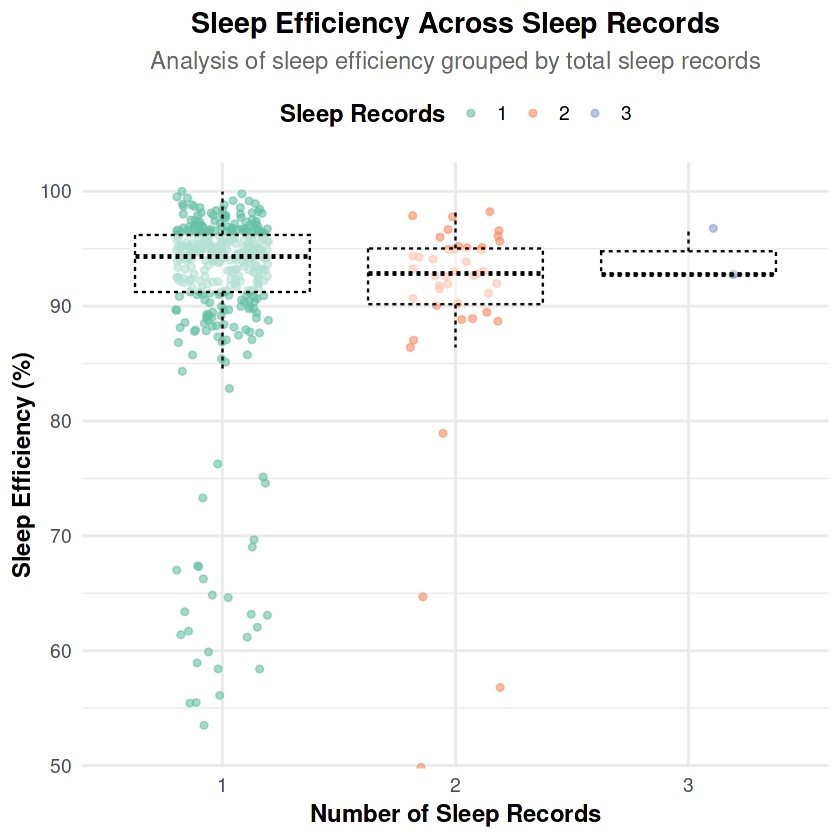

In [ ]:
mean_sleep_efficiency <- mean(sleep_new$efficiency)
print(mean_sleep_efficiency)


mean_sleep_records <- sleep_new %>% 
  filter(TotalSleepRecords == 3) %>% 
  summarize(mean_efficiency = mean(efficiency, na.rm = TRUE)) %>% 
  pull(mean_efficiency)

print(mean_sleep_records)

ggplot(sleep_new, aes(
  x = as.factor(TotalSleepRecords), 
  y = efficiency, 
  group = as.factor(TotalSleepRecords), 
  color = as.factor(TotalSleepRecords)
)) +
  geom_jitter(width = 0.2, alpha = 0.6) + # Add jitter for better visualization of overlapping points
  geom_boxplot(outlier.shape = NA, alpha = 0.5, linetype = "dashed", color = "black") + # Add boxplot for summary statistics
  labs(
    title = "Sleep Efficiency Across Sleep Records",
    subtitle = "Analysis of sleep efficiency grouped by total sleep records",
    x = "Number of Sleep Records",
    y = "Sleep Efficiency (%)",
    color = "Sleep Records"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5, color = "gray40"),
    axis.title = element_text(face = "bold"),
    legend.position = "top",
    legend.title = element_text(face = "bold")
  ) +
  scale_color_brewer(palette = "Set2") + # Use a clear and distinct color palette
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) # Add breathing room above

+ As the number of sleep records increases, the variability in sleep efficiency tends to decrease, especially in individuals with 3 Sleep Records


## 5. Share Process

### The Story

This analysis provides valuable insights to inform BellaBeat's marketing strategy.
The data from the Leaf bracelet reveals its potential to significantly improve the well-being and health of its users. Monitoring physical activity, sleep, and other metrics manually can be overwhelming, but the Leaf and the Bellabeat app simplify this process, empowering women to focus on their health without the burden of data interpretation.

### The audience
  The audience for this study will be women in general, as it is their desire to stay healthy and improve their physical condition. Therefore, it is relevant for everyone, from working women,9am to 5pm, to high-performance athletes.

### Final Conclusions
<img src="https://th.bing.com/th/id/OIP.atLFz3D7FmKW6BdyN6MalgHaE7?rs=1&pid=ImgDetMain" alt="Women Running" width="600" />

  + **Combatting Sedentary Lifestyles**: Sedentary behavior is a rising global concern. Tracking and increasing daily steps is a simple but effective strategy to counteract this issue and promote healthier livin;
  + **Walking as a Calorie-Burning Tool**: Walking is a powerful and accessible method to increase calorie expenditure. Our analysis demonstrates a clear link between increased daily steps and higher calorie burn, reinforcing the importance of an active lifestyle.
  + **Sleep Efficiency and Tracking**: Most users exhibit high sleep efficiency, which improves with consistent tracking. This suggests that tools like the Leaf can encourage better sleep patterns by providing actionable insights.
 
### Reccomendations

<img src="https://th.bing.com/th/id/R.43bf530a8caa3627d2abe9cd3cfa4ef9?rik=BUjU4j75%2fYZmpg&pid=ImgRaw&r=0" alt="Connecting the BellaBeat bracelet with the mobile app" width="600" />


  + 1. **Tracking daily steps**- Highlight the importance of step tracking for overall health. Notifications reminding users of daily step goals, progress, and achievements can motivate them to stay active and adopt healthier habits.
  + 2. **Notifications for Sleeping**- Use app notifications to guide users toward better sleep hygiene, such as reminders for bedtime and tips to improve sleep quality. Encouraging users to monitor their sleep data can foster better long-term habits and improve overall well-being.